In [ ]:
import numpy as np
from scipy import stats
import xarray as xr
import matplotlib.pyplot as plt
import proplot as pplt

# Paths
path = 'path'
t2m_path = f'{path}/ERA5_daily/t2m'
graphics_path = f'{path}/x_misch/proj_FDR/graphics'
sample_path = f'{path}/x_misch/proj_FDR/samples'

# Load temperature data (ONDJFMA, detrended and deseasonalised)
t2m = xr.open_mfdataset(f'{t2m_path}/t2m_1979-2022_ONDJFMA_detr_des.nc').t2m.sel(time=slice('1980', '2022'))

# Land-sea mask
lsm = xr.open_mfdataset(f'{t2m_path}/NoAm/lsm_05deg.nc').lsm
lsm = lsm.assign_coords(lon=lsm.lon.values - 180)

# SSW central dates
warming_dates = [
    "1980-02-29", "1981-03-04", "1981-12-04", "1984-02-24",
    "1985-01-01", "1987-01-23", "1987-12-08", "1988-03-14", "1989-02-21",
    "1998-12-15", "1999-02-26", "2000-03-20", "2001-02-11", "2001-12-30",
    "2003-01-18", "2004-01-05", "2006-01-21", "2007-02-24", "2008-02-22",
    "2009-01-24", "2010-02-09", "2010-03-24", "2013-01-06", "2018-02-12",
    "2019-01-02", "2021-01-05",
]
ssw_id = [np.datetime64(d) + np.timedelta64(11, 'h') for d in warming_dates]

# Functions

In [11]:
def select_time_series(event_times, lag, ref_times):
    """Return all time steps within `lag` days after each event that exist in ref_times."""
    time_series = []
    for t in event_times:
        for j in range(lag + 1):
            time_series.append(t + np.timedelta64(j, 'D'))
    good_series = [t for t in time_series if t in ref_times]
    if lag < 1:
        good_series = list(event_times)
    return good_series


def resample(in_data, sample_size, num_samples, steps, data_type):
    """Bootstrap resampling: draw `num_samples` composites of `sample_size` windows of length `steps+1`."""
    data = in_data.values
    samples = []
    for _ in range(num_samples):
        sample = []
        for _ in range(sample_size):
            n = np.random.randint(0, len(data) - steps)
            sample.append(np.nanmean(data[n:n + steps + 1], axis=0))
        samples.append(np.nanmean(sample, axis=0))
    if data_type == 'geo':
        samples = xr.DataArray(
            data=samples,
            dims=['sample', 'lat', 'lon'],
            coords={'lat': in_data.lat, 'lon': in_data.lon, 'sample': np.arange(num_samples)},
            name='samples',
        )
    return samples


def adjust_FDR(sorted_p, alpha_FDR, p_values, data_type, in_data):
    """Apply Benjamini-Hochberg FDR correction; return boolean significance mask and threshold index."""
    x = -1
    p_FDR = 0
    for i, p in enumerate(sorted_p):
        if p <= (i + 1) / len(sorted_p) * alpha_FDR:
            p_FDR = p
            x = i
    if p_FDR == 0:
        print('min_p_FDR = 0')
    elif p_FDR > 0.05:
        print(f'min_p_FDR = {p_FDR} > 0.05')
    else:
        print(f'p* (FDR) = {p_FDR}')
    p_values = p_values <= p_FDR
    if data_type == 'geo':
        p_values = xr.DataArray(
            data=p_values, dims=['lat', 'lon'],
            coords={'lat': in_data.lat, 'lon': in_data.lon}, name='p_values',
        )
    return p_values, x


def get_significance(in_data, anom, sample_size, num_samples, steps, data_type, sig_level,
                     saved_sample, sidedness, method, p_method):
    """
    Test whether the composite anomaly `anom` is significant against a bootstrap null distribution.

    Parameters
    ----------
    saved_sample : 'saved' | any
        If 'saved', load pre-computed samples from sample_path; otherwise generate them.
    method : 'local_tests' | None
        'local_tests' adjusts alpha_FDR using the proportion of locally significant grid points.
    p_method: 'empirical' | None
        'empirical' computes empirical p-values, otherwise p-values are based on a student t-test.
    sig_level : float
        If > 0, use a fixed significance level instead of FDR correction.
    sidedness : 'one' | 'two'
        One- or two-sided test.
    """
    if saved_sample == 'saved':
        samples = xr.open_mfdataset(
            f'{sample_path}/sample_{np.shape(in_data)[1:]}_{num_samples}.nc'
        ).samples
    else:
        samples = resample(in_data, sample_size, num_samples, steps, data_type)

    if p_method == 'empirical':
        if sidedness == 'one':
            p_values     = np.mean(samples.values < anom.values, axis=0)
            inv_p_values = np.mean(samples.values > anom.values, axis=0)
        elif sidedness == 'two':
            p_values     = np.mean(np.abs(samples.values) > np.abs(anom.values), axis=0)
            inv_p_values = p_values
    else:
        if sidedness == 'one':
            p_values = stats.ttest_ind(samples.values, anom.values, nan_policy='omit', equal_var=True, alternative='greater').pvalue
            inv_p_values = stats.ttest_ind(samples, anom.values, nan_policy='omit', equal_var=True, alternative='less').pvalue
        elif sidedness == 'two':
            p_values = stats.ttest_ind(samples.values, anom.values, nan_policy='omit', equal_var=True, alternative='two-sided').pvalue
            inv_p_values = p_values

    if data_type == 'geo':
        allp_min = xr.DataArray(data=p_values,     dims=['lat', 'lon'], coords={'lat': in_data.lat, 'lon': in_data.lon}, name='p_values')
        allp_max = xr.DataArray(data=inv_p_values, dims=['lat', 'lon'], coords={'lat': in_data.lat, 'lon': in_data.lon}, name='p_values')
    else:
        allp_min, allp_max = [], []

    sorted_p     = np.sort(p_values.flatten())
    inv_sorted_p = np.sort(inv_p_values.flatten())

    if method == 'local_tests':
        print(method)
        p_values_sig = p_values < 0.05
        ratio = np.sum(p_values_sig) / len(sorted_p)
        print(f'ratio: {ratio:.4f}')
        alpha_FDR = 0.1 * np.exp(-ratio)
        print(f'alpha = {alpha_FDR:.4f}')
    else:
        alpha_FDR = 0.1

    if sig_level == 0:
        p_values,     x1 = adjust_FDR(sorted_p,     alpha_FDR, p_values,     data_type, in_data)
        inv_p_values, x2 = adjust_FDR(inv_sorted_p, alpha_FDR, inv_p_values, data_type, in_data)
    else:
        p_values     = p_values     < sig_level
        inv_p_values = inv_p_values < sig_level
        x1, x2 = -1, -1
        if data_type == 'geo':
            p_values     = xr.DataArray(data=p_values,     dims=['lat', 'lon'], coords={'lat': in_data.lat, 'lon': in_data.lon}, name='p_values')
            inv_p_values = xr.DataArray(data=inv_p_values, dims=['lat', 'lon'], coords={'lat': in_data.lat, 'lon': in_data.lon}, name='p_values')

    p_values_min = p_values.where(anom < 0)
    p_values_max = inv_p_values.where(anom > 0)

    return [p_values_min, p_values_max], [sorted_p, inv_sorted_p], [x1, x2], [allp_min, allp_max], alpha_FDR


def plot_box(location, ax, color, label, **kwargs):
    """Draw a rectangular box on a map axis defined by [lat1, lat2, lon1, lon2]."""
    lat1, lat2, lon1, lon2 = location
    lats = np.arange(lat1, lat2 + 1)
    lons = np.arange(lon1, lon2 + 1)
    ax.plot([lon1] * len(lats), lats, c=color, label=label, **kwargs)
    ax.plot([lon2] * len(lats), lats, c=color, **kwargs)
    ax.plot(lons, [lat1] * len(lons), c=color, **kwargs)
    ax.plot(lons, [lat2] * len(lons), c=color, **kwargs)

# Figures

## Main figures

0 1 p* (FDR) = 0.00985755453796217
p* (FDR) = 0.00849637053993521
2 p* (FDR) = 0.00985755453796217
p* (FDR) = 0.00849637053993521
3 min_p_FDR = 0.09796882008635975 > 0.05
min_p_FDR = 0


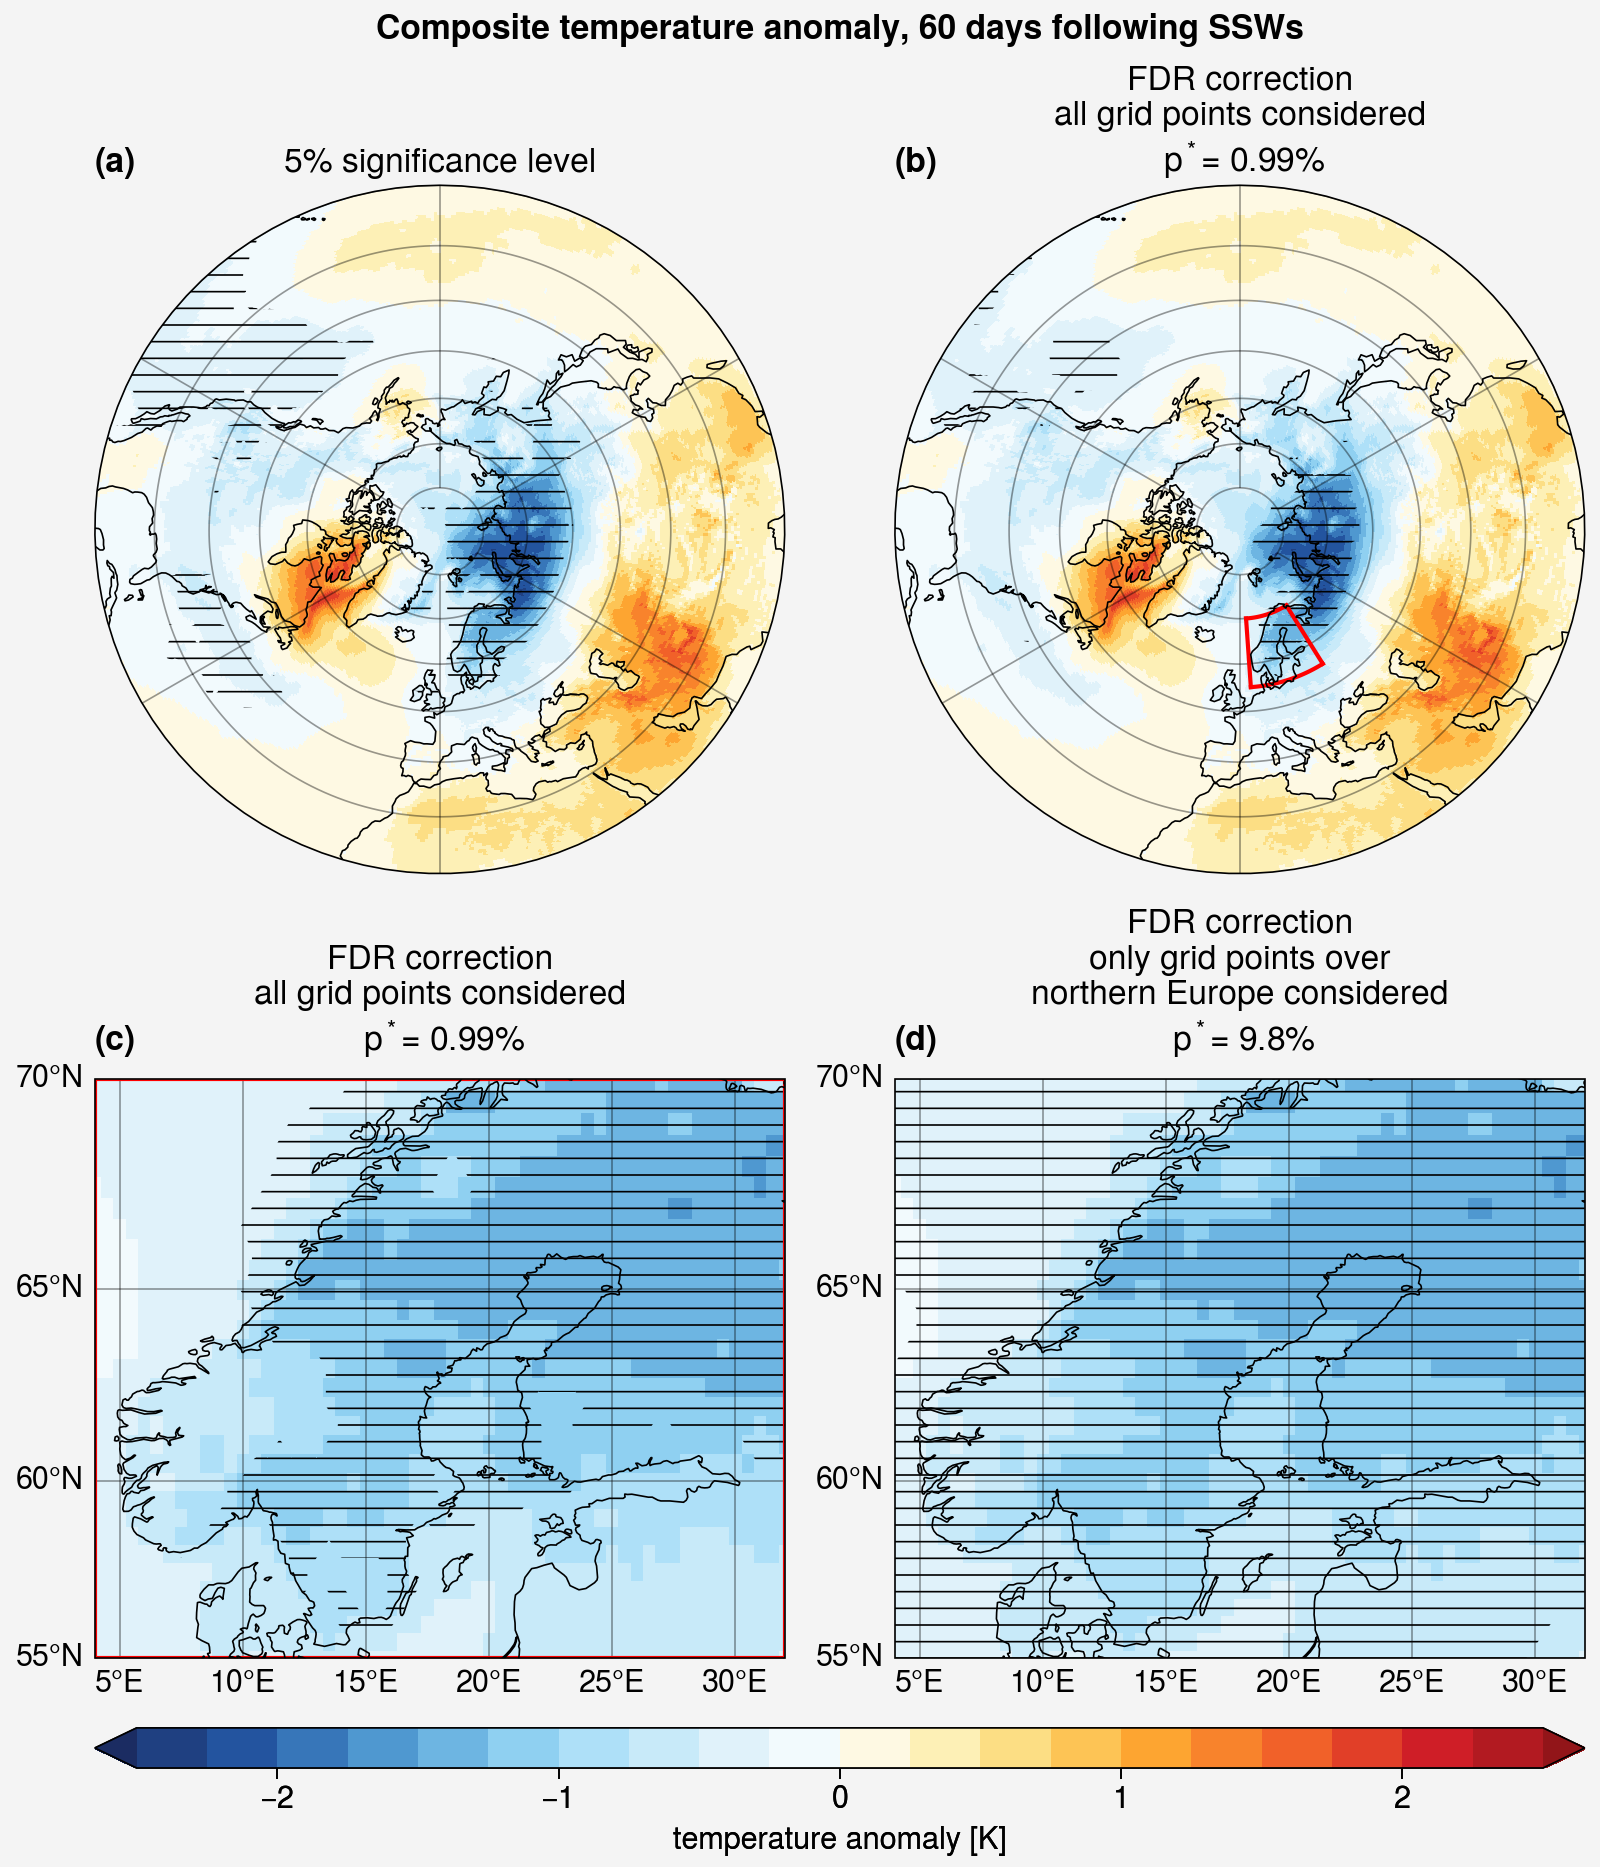

In [13]:
# Figure 1 – Composite temperature anomaly maps (60 days post-SSW)
plt.rcParams.update({'font.size': 11})

fields    = [t2m, t2m, t2m, t2m.sel(lon=slice(4, 32), lat=slice(55, 70))]
titles    = [
    '5% significance level',
    'FDR correction\nall grid points considered',
    'FDR correction\nall grid points considered',
    'FDR correction\nonly grid points over\nnorthern Europe considered',
]
resos     = ['lo', 'lo', 'med', 'med']
sig_levels = [0.05, 0, 0, 0]

dates = select_time_series(ssw_id + np.timedelta64(1, 'D'), 60, t2m.time.values)
all_pvalues, all_x, all_grid_pvalues = [], [], []

fig, ax = pplt.subplots(
    nrows=2, ncols=2, width=8,
    proj={1: 'npstere', 2: 'npstere', 3: 'mill', 4: 'mill'},
    suptitle='Composite temperature anomaly, 60 days following SSWs',
    abc='(a)', sharey=True,
)

for i in range(4):
    print(i, end=' ')
    field = fields[i]
    composite = field.sel(time=dates).drop_duplicates(dim='time', keep='first').mean('time')

    m = ax[i].pcolormesh(
        field.lon, field.lat, composite.values,
        cmap='ColdHot', vmin=-2.5, vmax=2.5, N=20, extend='both',
        globe=False, norm=pplt.Norm('diverging', fair=False),
    )
    significance, pvalues, positions, grid_pvalues, alpha_FDR = get_significance(
        field, composite, len(ssw_id), 10000, 60, 'geo', sig_levels[i], 'saved', 'one', 0, None,
    )
    all_pvalues.append(pvalues)
    all_x.append(positions)
    all_grid_pvalues.append(grid_pvalues)

    ax[i].contourf(
        significance[0].lon, significance[0].lat, significance[0],
        colors='none', hatches=[None, '--'], levels=[0.75, 1], extend='both',
    )
    title = titles[i]
    if i != 0:
        if positions[0] >= 0:
            title += f'\n p$^*$= {np.round(100 * pvalues[0][positions[0]], 2)}%'
        else:
            title += '\n no significant grid points'
    ax[i].format(title=title, coast=True, gridalpha=0.4, borders=False, ocean=False, reso=resos[i])

    if i > 1:
        ax[i].format(
            lonlim=(int(field.lon.min()), int(field.lon.max())),
            latlim=(int(field.lat.min()), int(field.lat.max())),
            latlabels=True, lonlabels=True, lonlines=5, latlines=5,
        )
    else:
        ax[i].format(boundinglat=20)

ax[-2].format(lonlim=(4, 32), latlim=(55, 70))
plot_box([55, 70, 4, 32], ax[1], 'red', '')
plot_box([55, 70, 4, 32], ax[2], 'red', '')

fig.colorbar(m, label='temperature anomaly [K]', loc='b', labelsize=11, ticks=1)
fig.savefig(f'{graphics_path}/map_SSW.png', dpi=400)

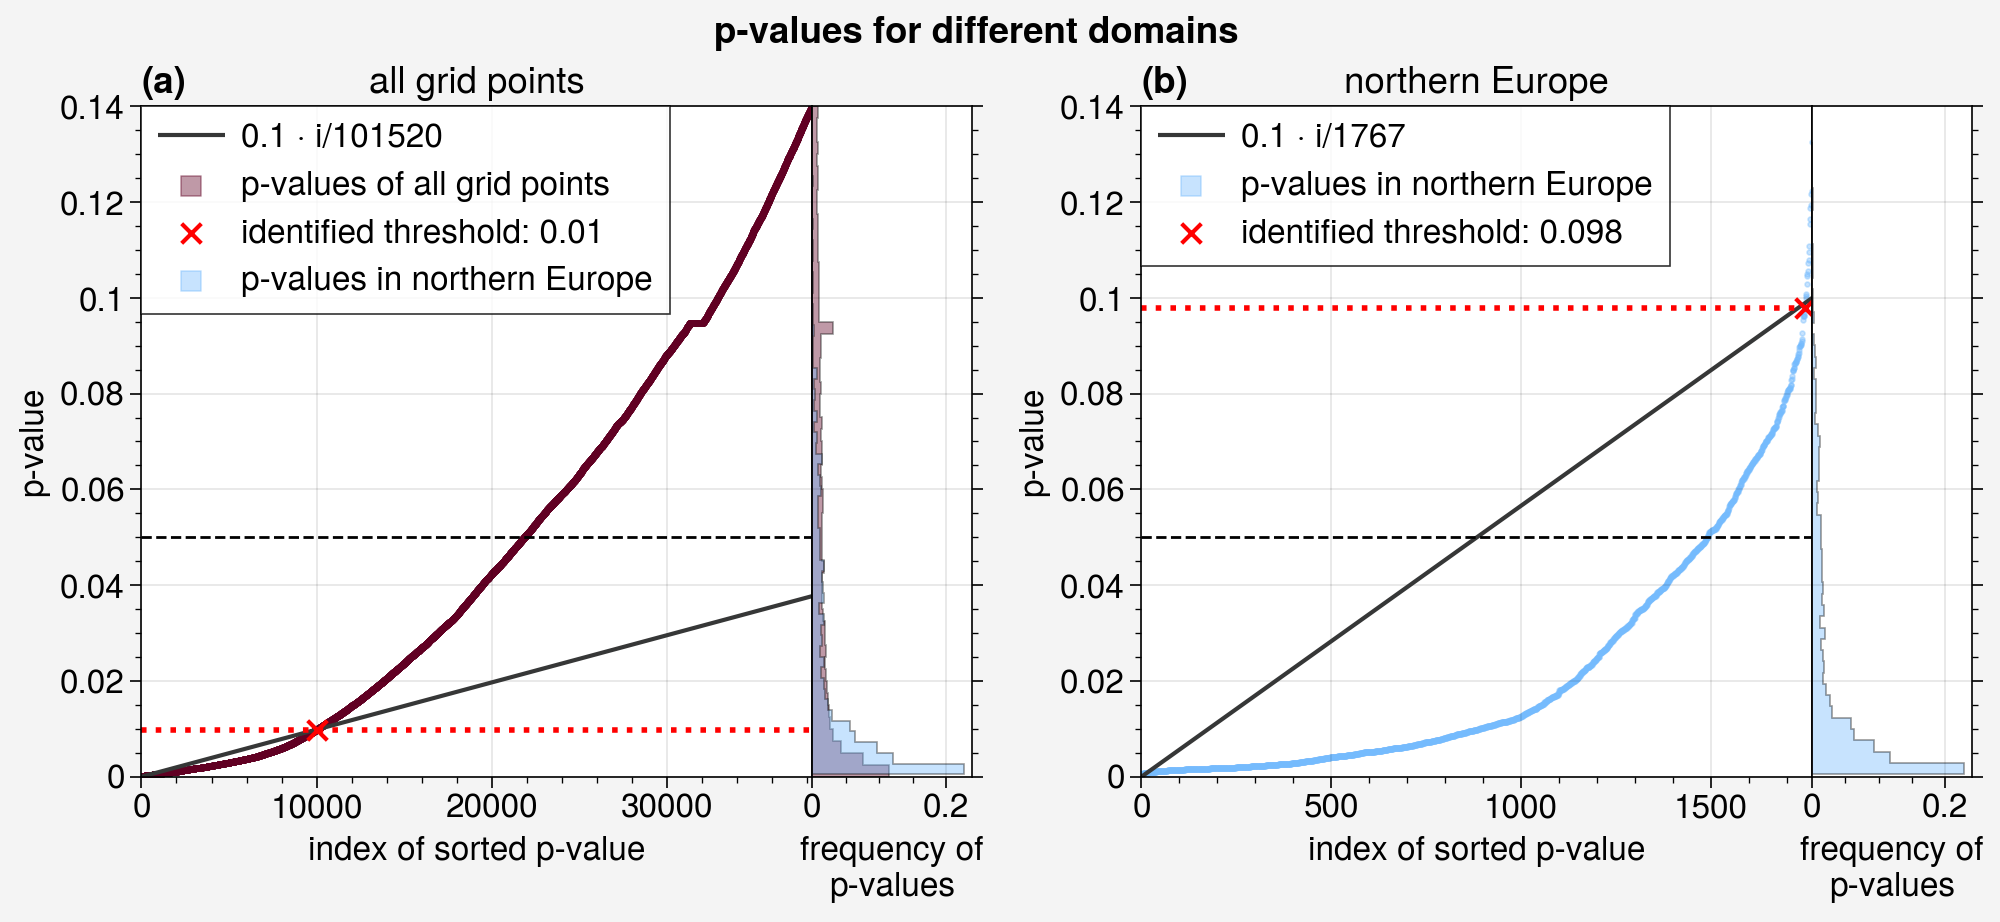

In [6]:
# Figure 2 – Sorted p-values for global and northern-Europe domains
plt.rcParams.update({'font.size': 12})

p_lists = [
    all_pvalues[2][0][np.where(all_pvalues[2][0] <= 0.14)],
    all_pvalues[3][0],
]
lengths       = [all_pvalues[2][0], all_pvalues[3][0]]
position_list = [all_x[2][0], all_x[3][0]]
titles  = ['all grid points', 'northern Europe']
colors  = ['burgundy', 'sky blue']
labels  = ['p-values of all grid points', 'p-values in northern Europe']

Scandp = all_grid_pvalues[2][0].sel(lon=slice(4, 32), lat=slice(55, 70)).values
Scandp = np.sort(Scandp[np.where(Scandp <= 0.14)].flatten())

fig, axs = pplt.subplots(
    ncols=2, nrows=1, width=10, share=False,
    abc='(a)', suptitle='p-values for different domains', sharey=False,
)

for i in range(2):
    p_list, x = p_lists[i], position_list[i]

    axs[i].scatter(np.arange(len(p_list)), p_list, s=3, c=colors[i], alpha=0.4, label='')
    axs[i].scatter([0], [1], m='s', s=50, c=colors[i], alpha=0.4, label=labels[i])
    axs[i].plot(
        np.arange(len(p_list)),
        np.arange(len(p_list)) * 0.1 / len(lengths[i]),
        c='dark gray', label=f'0.1 · i/{len(lengths[i])}',
    )
    if x >= 0:
        axs[i].scatter([x], [p_list[x]], m='x', s=50, c='red',
                       label=f'identified threshold: {np.round(p_list[x], 3)}', zorder=103)
        axs[i].axhline(p_list[x], color='red', linewidth=2, linestyle=':')
    axs[i].axhline(0.05, color='black', linewidth=1, linestyle='--')
    axs[i].format(title=titles[i], xlabel='index of sorted p-value', ylabel='p-value')

    px = axs[i].panel('r', space=0, width=0.8)
    px.histh(p_list, bins=14 * 4, fill=True, ec='k', color=colors[i], alpha=0.4,
             weights=np.ones_like(p_list) / len(p_list))
    if i == 0:
        px.histh(Scandp, bins=14 * 4, fill=True, ec='k', color='sky blue', alpha=0.4,
                 weights=np.ones_like(Scandp) / len(Scandp))
        axs[i].scatter([0], [1], m='s', s=50, c='sky blue', alpha=0.4, label='p-values in northern Europe')
    px.format(xlabel='frequency of\np-values')

axs[0].legend(ncol=1)
axs[1].legend(ncol=1)
axs.format(ylim=(0, 0.14))

fig.savefig(f'{graphics_path}/pvalues_SSW.png', dpi=400)

## Appendix figures

0 

1 p* (FDR) = 0.0099
p* (FDR) = 0.0084
2 p* (FDR) = 0.0099
p* (FDR) = 0.0084
3 min_p_FDR = 0.0988 > 0.05
min_p_FDR = 0


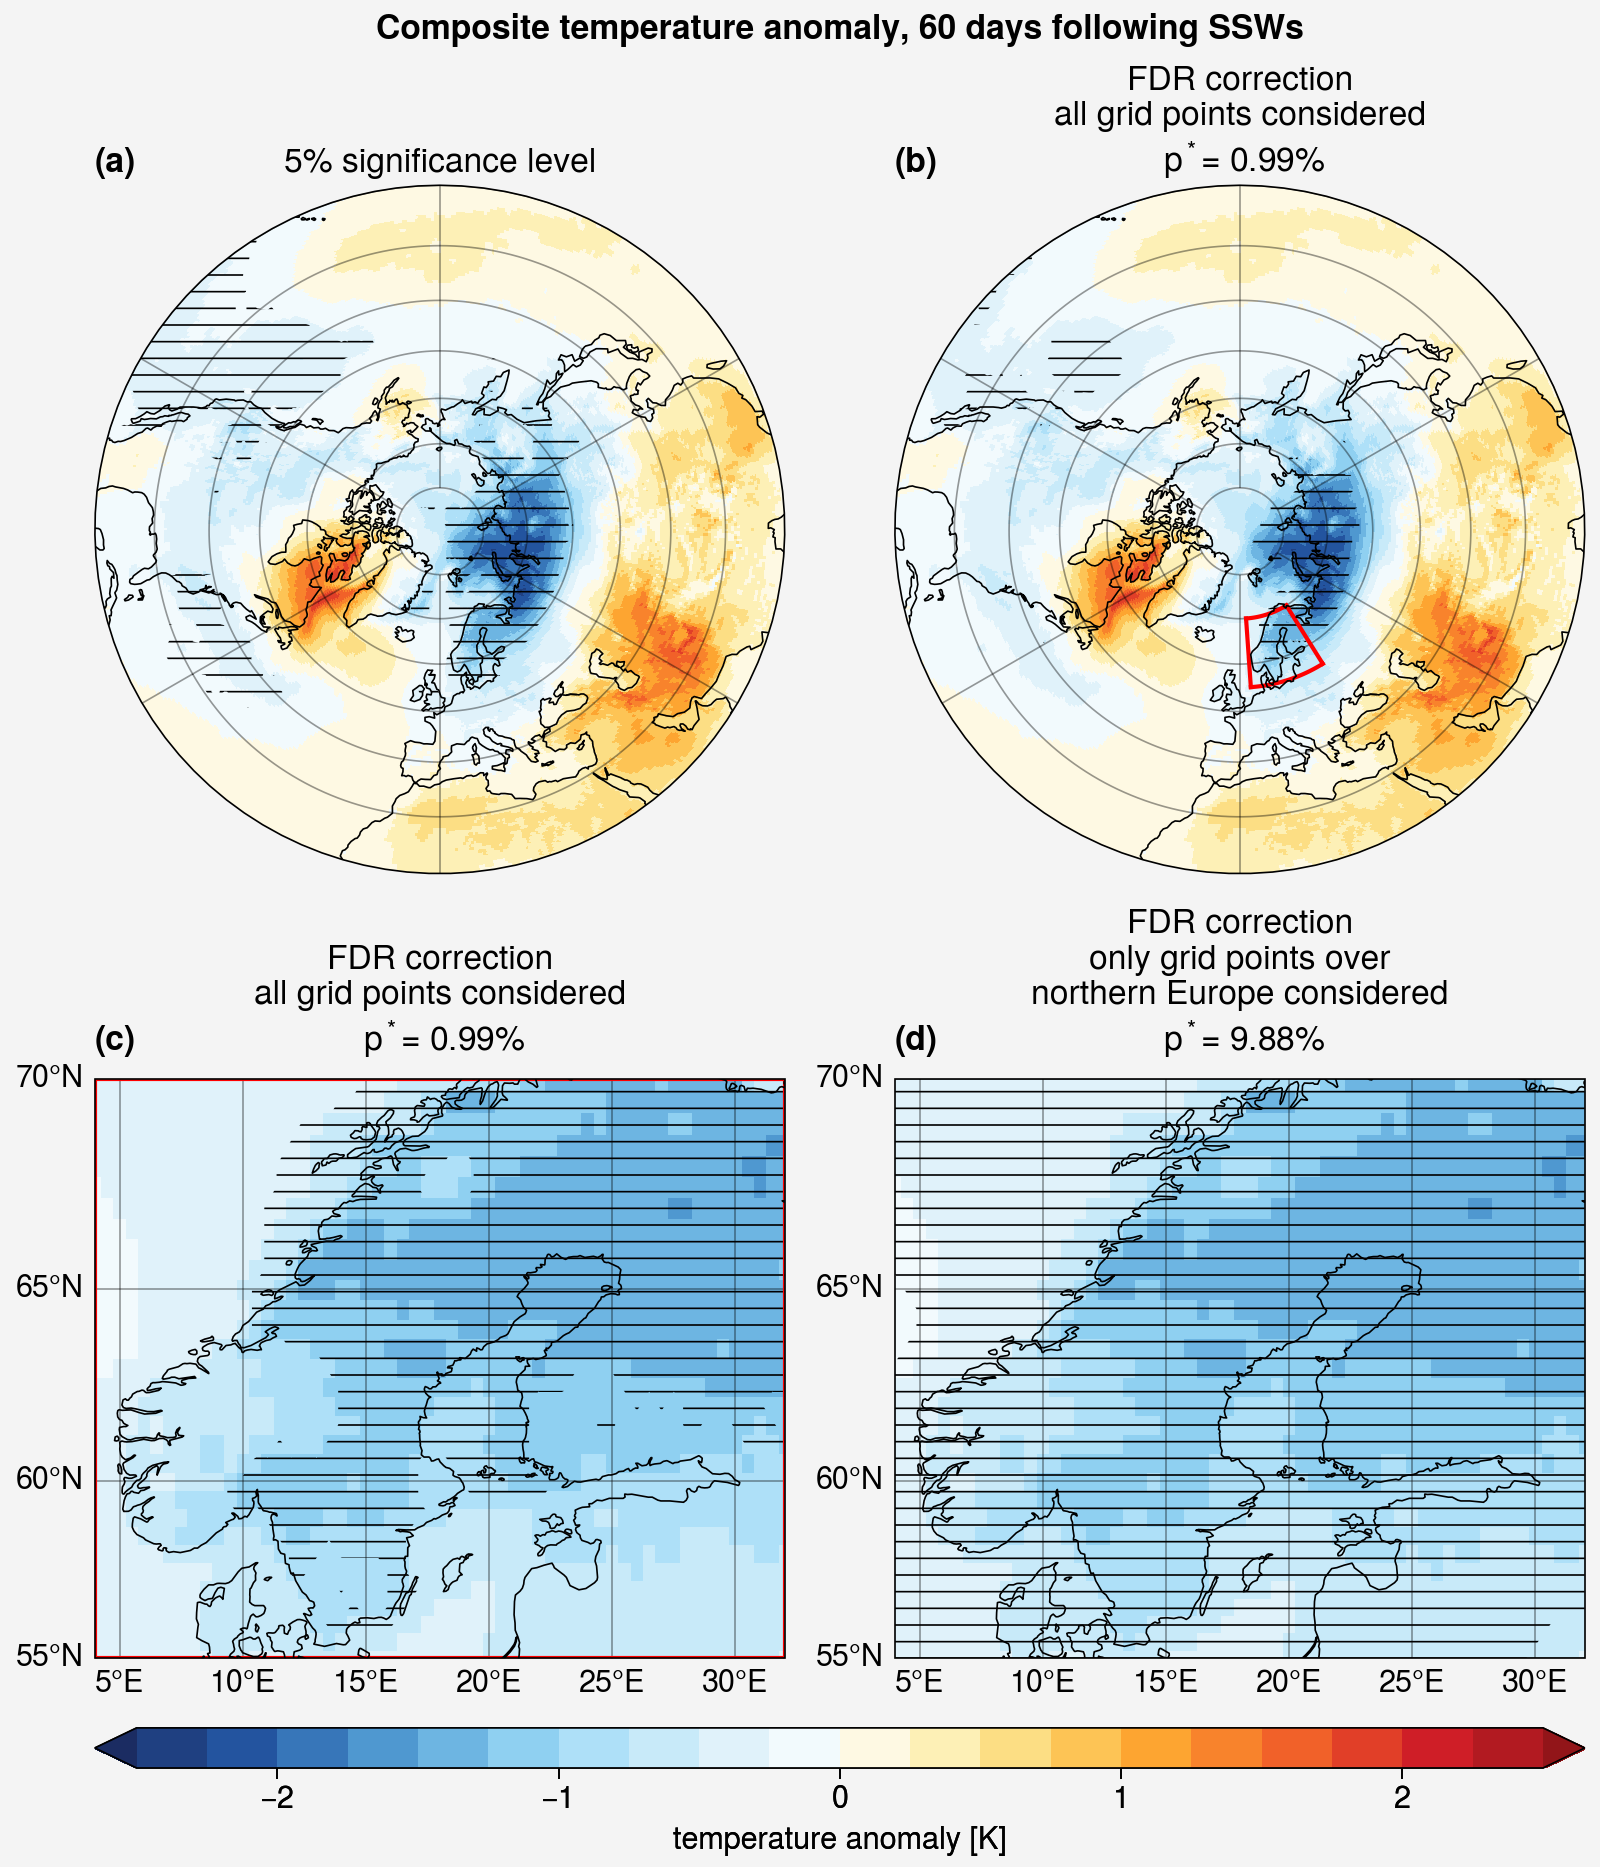

In [14]:
# Appendix Figure 1 – Composite temperature anomaly maps (60 days post-SSW) with empirical p-values
plt.rcParams.update({'font.size': 11})

fields    = [t2m, t2m, t2m, t2m.sel(lon=slice(4, 32), lat=slice(55, 70))]
titles    = [
    '5% significance level',
    'FDR correction\nall grid points considered',
    'FDR correction\nall grid points considered',
    'FDR correction\nonly grid points over\nnorthern Europe considered',
]
resos     = ['lo', 'lo', 'med', 'med']
sig_levels = [0.05, 0, 0, 0]

dates = select_time_series(ssw_id + np.timedelta64(1, 'D'), 60, t2m.time.values)
all_pvalues, all_x, all_grid_pvalues = [], [], []

fig, ax = pplt.subplots(
    nrows=2, ncols=2, width=8,
    proj={1: 'npstere', 2: 'npstere', 3: 'mill', 4: 'mill'},
    suptitle='Composite temperature anomaly, 60 days following SSWs',
    abc='(a)', sharey=True,
)

for i in range(4):
    print(i, end=' ')
    field = fields[i]
    composite = field.sel(time=dates).drop_duplicates(dim='time', keep='first').mean('time')

    m = ax[i].pcolormesh(
        field.lon, field.lat, composite.values,
        cmap='ColdHot', vmin=-2.5, vmax=2.5, N=20, extend='both',
        globe=False, norm=pplt.Norm('diverging', fair=False),
    )
    significance, pvalues, positions, grid_pvalues, alpha_FDR = get_significance(
        field, composite, len(ssw_id), 10000, 60, 'geo', sig_levels[i], 'saved', 'one', 0, 'empirical',
    )
    all_pvalues.append(pvalues)
    all_x.append(positions)
    all_grid_pvalues.append(grid_pvalues)

    ax[i].contourf(
        significance[0].lon, significance[0].lat, significance[0],
        colors='none', hatches=[None, '--'], levels=[0.75, 1], extend='both',
    )
    title = titles[i]
    if i != 0:
        if positions[0] >= 0:
            title += f'\n p$^*$= {np.round(100 * pvalues[0][positions[0]], 2)}%'
        else:
            title += '\n no significant grid points'
    ax[i].format(title=title, coast=True, gridalpha=0.4, borders=False, ocean=False, reso=resos[i])

    if i > 1:
        ax[i].format(
            lonlim=(int(field.lon.min()), int(field.lon.max())),
            latlim=(int(field.lat.min()), int(field.lat.max())),
            latlabels=True, lonlabels=True, lonlines=5, latlines=5,
        )
    else:
        ax[i].format(boundinglat=20)

ax[-2].format(lonlim=(4, 32), latlim=(55, 70))
plot_box([55, 70, 4, 32], ax[1], 'red', '')
plot_box([55, 70, 4, 32], ax[2], 'red', '')

fig.colorbar(m, label='temperature anomaly [K]', loc='b', labelsize=11, ticks=1)
fig.savefig(f'{graphics_path}/map_SSW_empir.png', dpi=400)

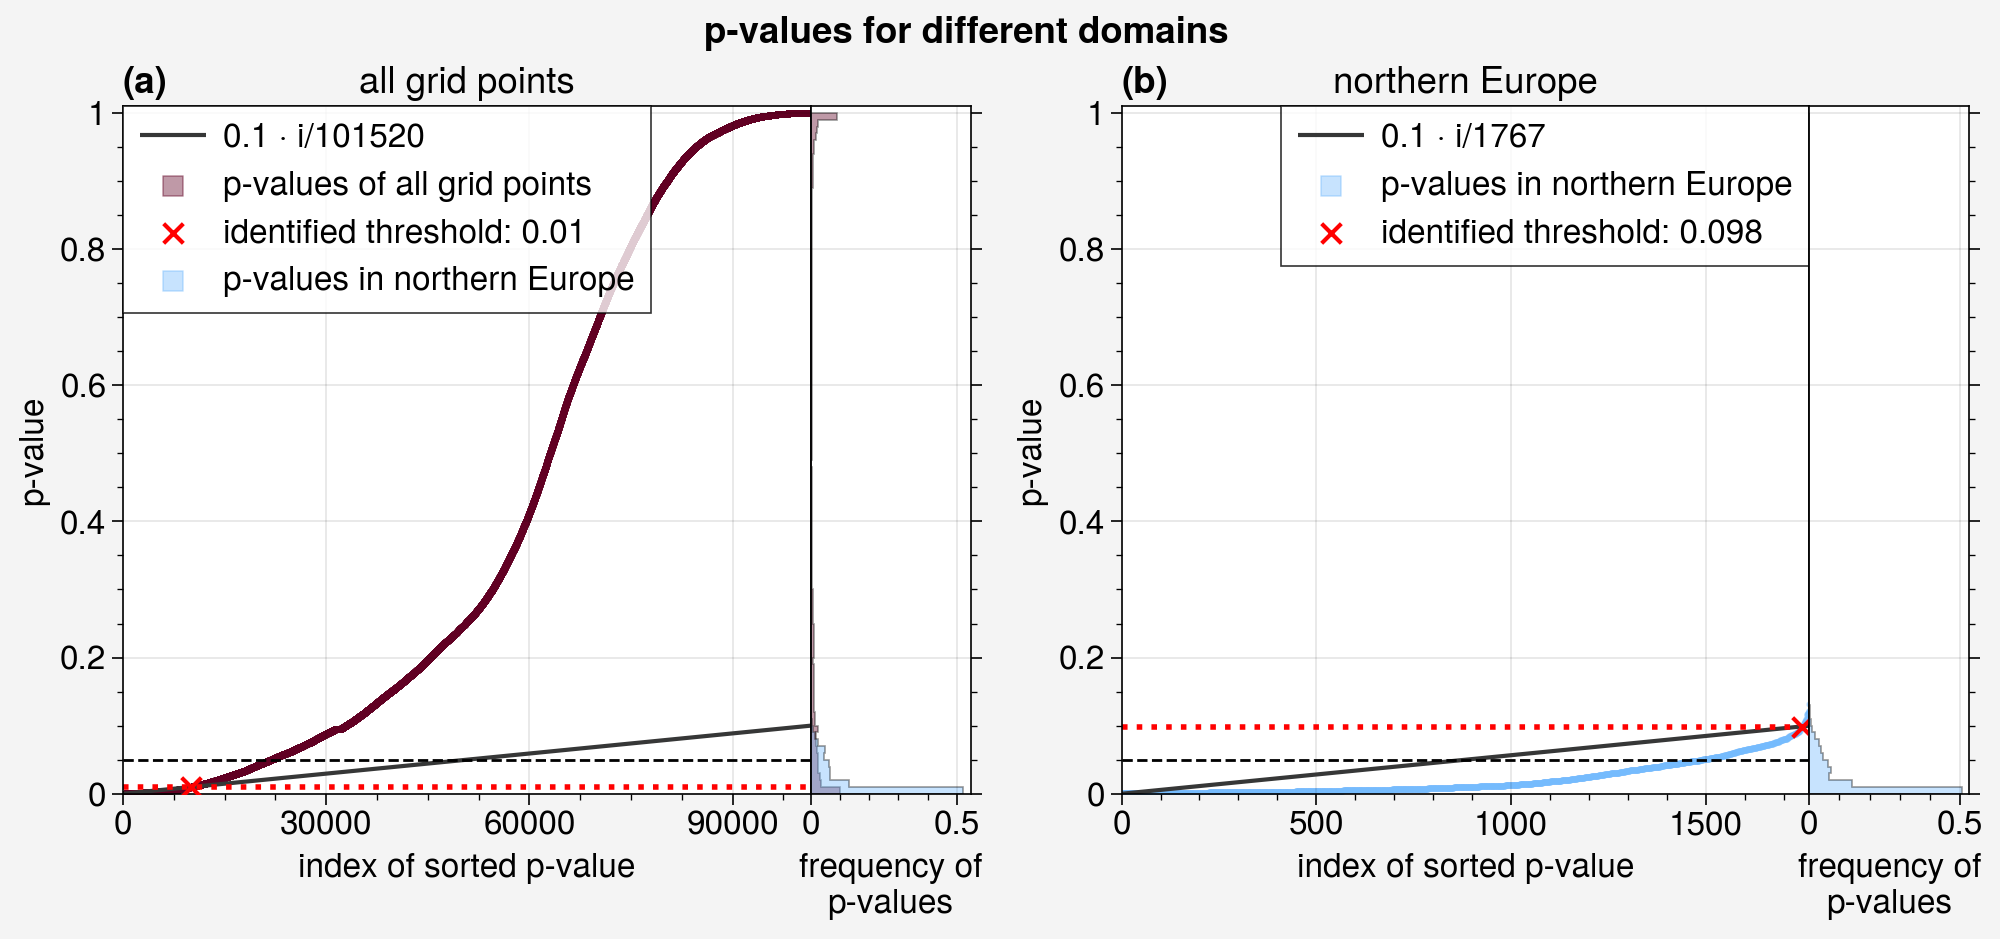

In [ ]:
# Appendix Figure 2 – Sorted p-values, full range (ylim 0–1)
plt.rcParams.update({'font.size': 12})

p_lists = [all_pvalues[2][0], all_pvalues[3][0]]
lengths       = [all_pvalues[2][0], all_pvalues[3][0]]
position_list = [all_x[2][0], all_x[3][0]]
titles  = ['all grid points', 'northern Europe']
colors  = ['burgundy', 'sky blue']
labels  = ['p-values of all grid points', 'p-values in northern Europe']

Scandp = all_grid_pvalues[2][0].sel(lon=slice(4, 32), lat=slice(55, 70)).values
Scandp = np.sort(Scandp[np.where(Scandp <= 0.14)].flatten())

fig, axs = pplt.subplots(
    ncols=2, nrows=1, width=10, share=False,
    abc='(a)', suptitle='p-values for different domains', sharey=False,
)

for i in range(2):
    p_list, x = p_lists[i], position_list[i]

    axs[i].scatter(np.arange(len(p_list)), p_list, s=3, c=colors[i], alpha=0.4, label='')
    axs[i].scatter([0], [2], m='s', s=50, c=colors[i], alpha=0.4, label=labels[i])
    axs[i].plot(
        np.arange(len(p_list)),
        np.arange(len(p_list)) * 0.1 / len(lengths[i]),
        c='dark gray', label=f'0.1 · i/{len(lengths[i])}',
    )
    if x >= 0:
        axs[i].scatter([x], [p_list[x]], m='x', s=50, c='red',
                       label=f'identified threshold: {np.round(p_list[x], 3)}', zorder=103)
        axs[i].axhline(p_list[x], color='red', linewidth=2, linestyle=':')
    axs[i].axhline(0.05, color='black', linewidth=1, linestyle='--') 
    axs[i].format(title=titles[i], xlabel='index of sorted p-value', ylabel='p-value')

    px = axs[i].panel('r', space=0, width=0.8)
    px.histh(p_list, bins=np.arange(0, 1.01, 0.01), fill=True, ec='k', color=colors[i], alpha=0.4,
             weights=np.ones_like(p_list) / len(p_list))
    if i == 0:
        px.histh(Scandp, bins=np.arange(0, 1, 0.01), fill=True, ec='k', color='sky blue', alpha=0.4,
                 weights=np.ones_like(Scandp) / len(Scandp))
        axs[i].scatter([0], [2], m='s', s=50, c='sky blue', alpha=0.4, label='p-values in northern Europe')
    px.format(xlabel='frequency of\np-values')

axs[0].format(xticks=30000)
axs[0].legend(ncol=1)
axs[1].legend(ncol=1)
axs.format(ylim=(0, 1.01))

fig.savefig(f'{graphics_path}/pvalues_SSW_all.png', dpi=400)

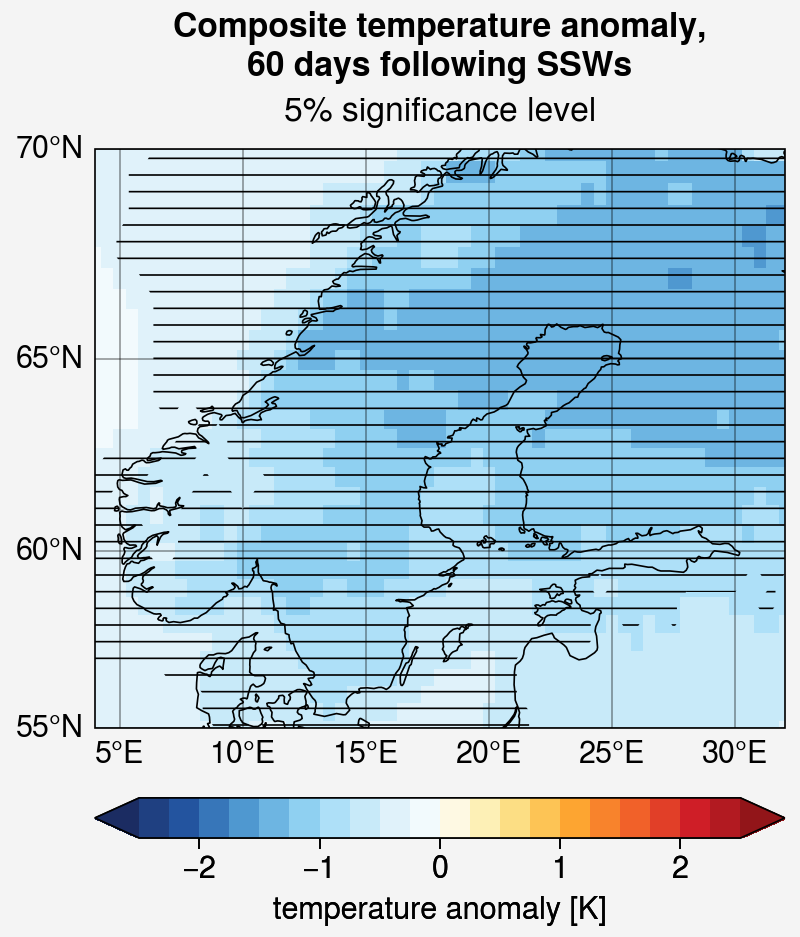

In [ ]:
# Appendix Figure 3 – Northern Europe domain, 5% significance level
plt.rcParams.update({'font.size': 11})

field      = t2m.sel(lon=slice(4, 32), lat=slice(55, 70))
sig_level  = 0.05
dates      = select_time_series(ssw_id + np.timedelta64(1, 'D'), 60, t2m.time.values)
composite  = field.sel(time=dates).drop_duplicates(dim='time', keep='first').mean('time')

fig, ax = pplt.subplots(
    nrows=1, ncols=1, width=4, proj='mill',
    suptitle='Composite temperature anomaly,\n60 days following SSWs',
)

m = ax[0].pcolormesh(
    field.lon, field.lat, composite.values,
    cmap='ColdHot', vmin=-2.5, vmax=2.5, N=20, extend='both',
    globe=False, norm=pplt.Norm('diverging', fair=False),
)
significance, *_ = get_significance(
    field, composite, len(ssw_id), 10000, 60, 'geo', sig_level, 'saved', 'one', 0, None, 
)
ax[0].contourf(
    significance[0].lon, significance[0].lat, significance[0],
    colors='none', hatches=[None, '--'], levels=[0.75, 1], extend='both',
)
ax[0].format(
    title='5% significance level',
    coast=True, gridalpha=0.4, borders=False, ocean=False, reso='med',
    lonlim=(int(field.lon.min()), int(field.lon.max())),
    latlim=(int(field.lat.min()), int(field.lat.max())),
    latlabels=True, lonlabels=True, lonlines=5, latlines=5,
)
fig.colorbar(m, label='temperature anomaly [K]', loc='b', labelsize=11, ticks=1)
fig.savefig(f'{graphics_path}/map_SSW_nEur_05perc.png', dpi=400)

local_tests
ratio: 0.2093
alpha = 0.0811
p* (FDR) = 0.006010020733973391
p* (FDR) = 0.006363064522034362
local_tests
ratio: 0.8019
alpha = 0.0448
p* (FDR) = 0.031124818648150126
min_p_FDR = 0


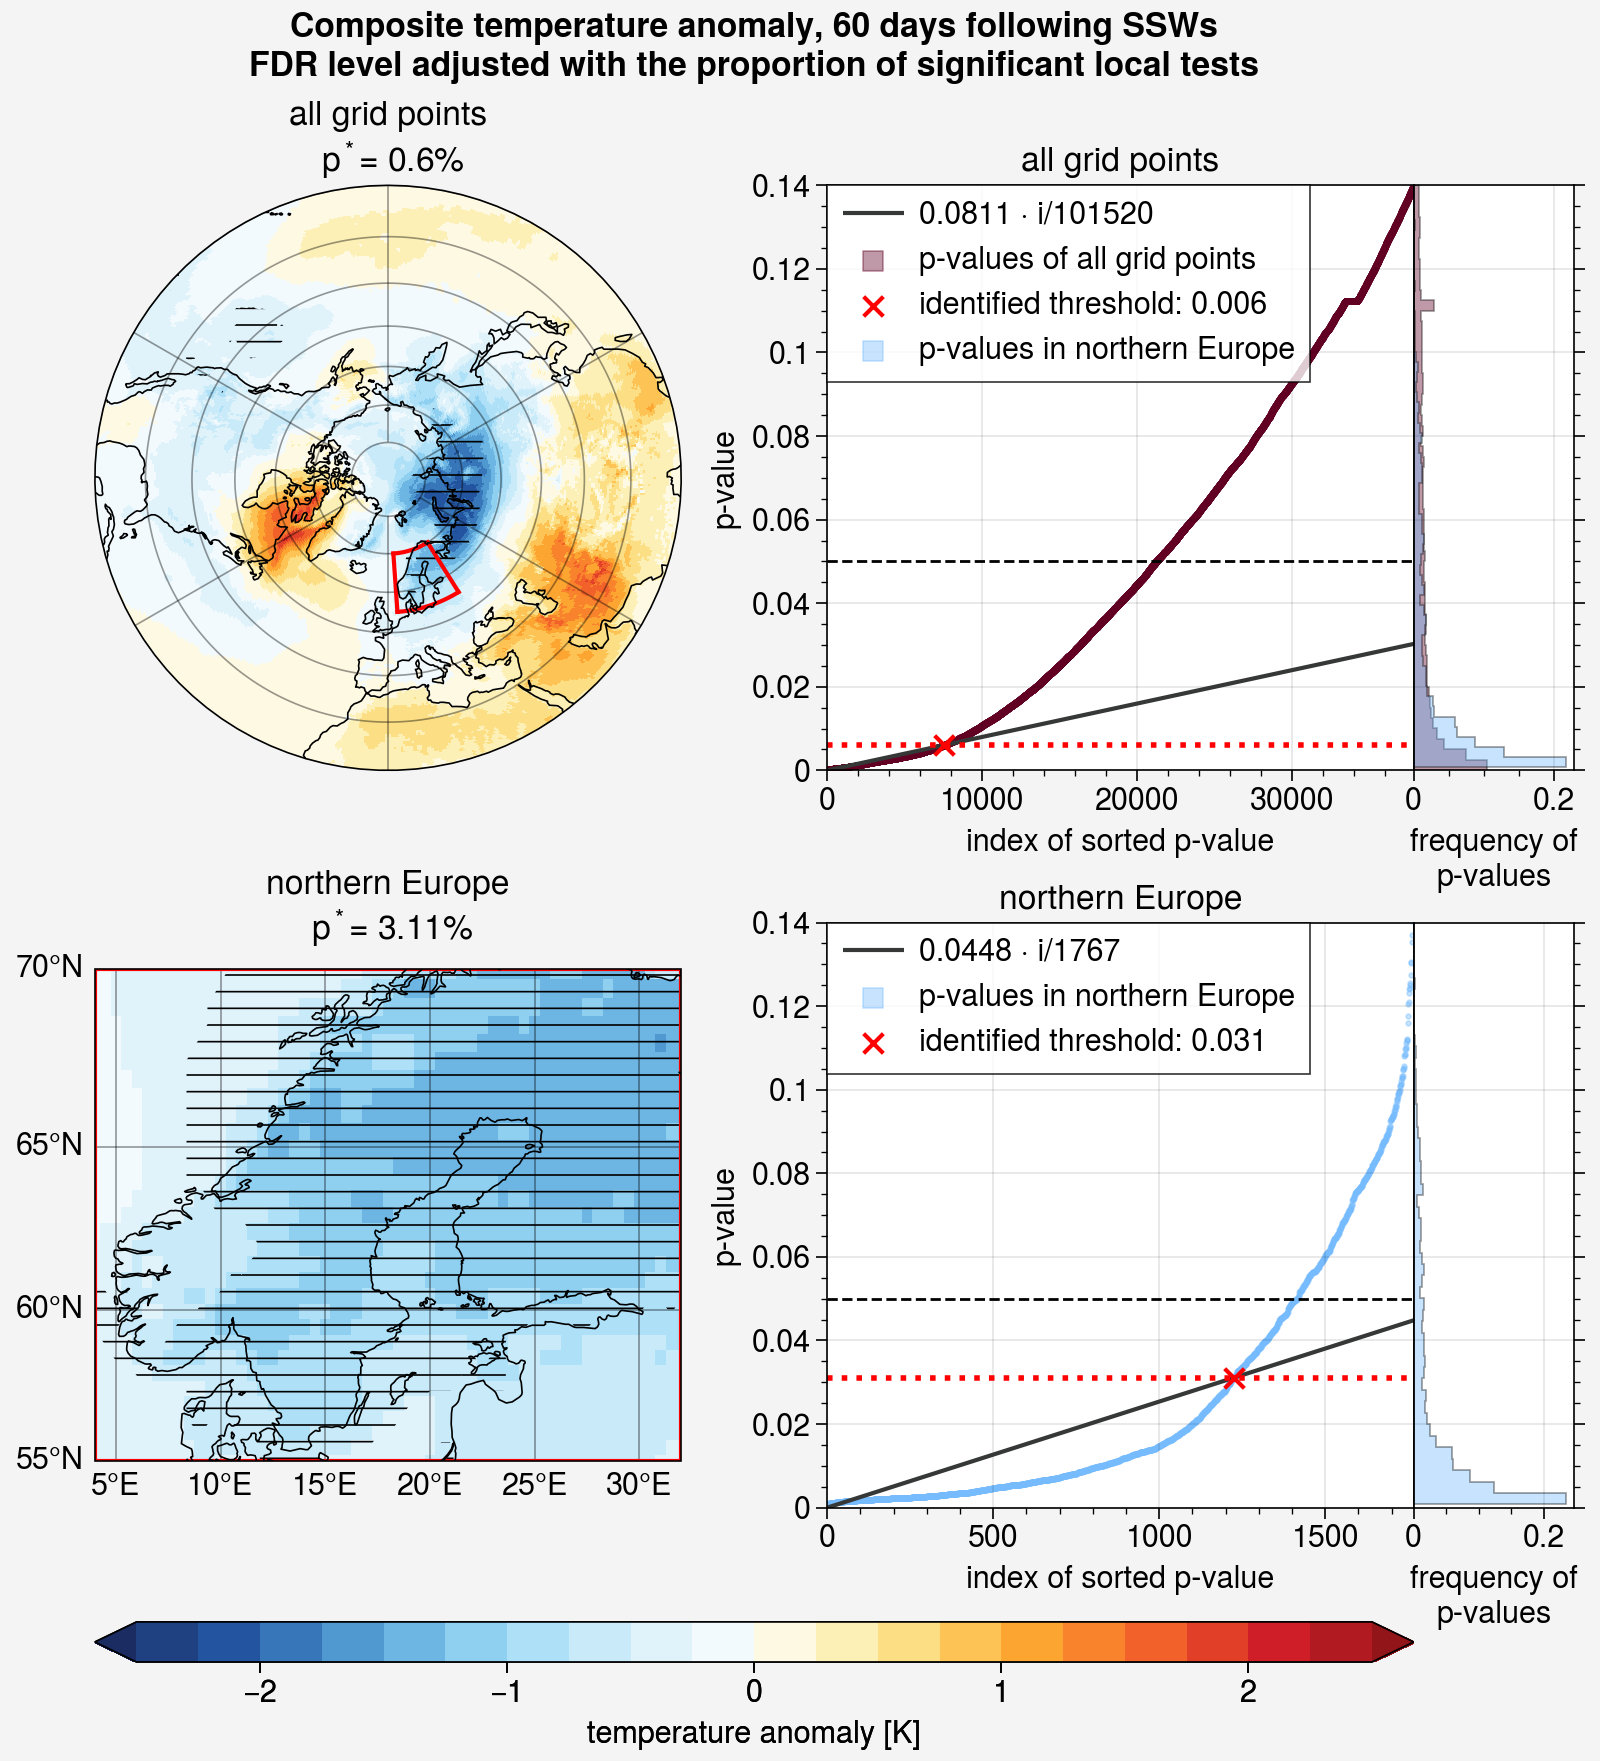

In [ ]:
# Appendix Figure 4 – FDR with locally-adjusted alpha (local_tests method)
method = 'local_tests'
method_names = {
    None:          'constant FDR level of 0.1',
    'local_tests': 'FDR level adjusted with the proportion of significant local tests',
}

plt.rcParams.update({'font.size': 11})

fields     = [t2m, t2m.sel(lon=slice(4, 32), lat=slice(55, 70))]
titles     = ['all grid points', 'northern Europe']
resos      = ['lo', 'med']
sig_levels = [0, 0]
dates      = select_time_series(ssw_id + np.timedelta64(1, 'D'), 60, t2m.time.values)
all_pvalues_ap, all_x_ap, all_grid_pvalues_ap, all_alpha_FDR_ap = [], [], [], []

fig, ax = pplt.subplots(
    nrows=2, ncols=2, width=8,
    proj={1: 'npstere', 3: 'mill'},
    sharex=False, sharey=False,
    suptitle=f'Composite temperature anomaly, 60 days following SSWs\n{method_names[method]}',
)

# --- Map panels (left column: ax[0], ax[2]) ---
for i in range(2):
    field = fields[i]
    composite = field.drop_duplicates(dim='time', keep='first').sel(time=dates).mean('time')

    m = ax[2 * i].pcolormesh(
        field.lon, field.lat, composite.values,
        cmap='ColdHot', vmin=-2.5, vmax=2.5, N=20, extend='both',
        globe=False, norm=pplt.Norm('diverging', fair=False),
    )
    significance, pvalues, positions, grid_pvalues, alpha_FDR = get_significance(
        field, composite, len(ssw_id), 10000, 60, 'geo', sig_levels[i], 'saved', 'one', method, None,
    )
    all_pvalues_ap.append(pvalues)
    all_x_ap.append(positions)
    all_grid_pvalues_ap.append(grid_pvalues)
    all_alpha_FDR_ap.append(alpha_FDR)

    ax[2 * i].contourf(
        significance[0].lon, significance[0].lat, significance[0],
        colors='none', hatches=[None, '--'], levels=[0.75, 1], extend='both',
    )
    if alpha_FDR > 0:
        title = f'{titles[i]}\n p$^*$= {np.round(100 * pvalues[0][positions[0]], 2)}%'
    else:
        title = f'{titles[i]}\n no significance detected'
    ax[2 * i].format(title=title, coast=True, gridalpha=0.4, borders=False, ocean=False, reso=resos[i])

ax[0].format(boundinglat=20)
ax[2].format(
    lonlim=(int(fields[1].lon.min()), int(fields[1].lon.max())),
    latlim=(int(fields[1].lat.min()), int(fields[1].lat.max())),
    latlabels=True, lonlabels=True, lonlines=5, latlines=5,
)
plot_box([55, 70, 4, 32], ax[0], 'red', '')
plot_box([55, 70, 4, 32], ax[2], 'red', '')

# --- p-value scatter panels (right column: ax[1], ax[3]) ---
p_lists = [
    all_pvalues_ap[0][0][np.where(all_pvalues_ap[0][0] <= 0.14)],
    all_pvalues_ap[1][0],
]
lengths       = [all_pvalues_ap[0][0], all_pvalues_ap[1][0]]
position_list = [all_x_ap[0][0], all_x_ap[1][0]]
colors  = ['burgundy', 'sky blue']
labels  = ['p-values of all grid points', 'p-values in northern Europe']

Scandp = all_grid_pvalues_ap[0][0].sel(lon=slice(4, 32), lat=slice(55, 70)).values
Scandp = np.sort(Scandp[np.where(Scandp <= 0.14)].flatten())

for i in range(2):
    p_list, x = p_lists[i], position_list[i]

    ax[2 * i + 1].scatter(np.arange(len(p_list)), p_list, s=3, c=colors[i], alpha=0.4, label='')
    ax[2 * i + 1].scatter([0], [2], m='s', s=50, c=colors[i], alpha=0.4, label=labels[i])
    ax[2 * i + 1].plot(
        np.arange(len(p_list)),
        np.arange(len(p_list)) * all_alpha_FDR_ap[i] / len(lengths[i]),
        c='dark gray', label=f'{all_alpha_FDR_ap[i]:.4f} · i/{len(lengths[i])}',
    )
    if x >= 0:
        ax[2 * i + 1].scatter([x], [p_list[x]], m='x', s=50, c='red',
                               label=f'identified threshold: {np.round(p_list[x], 3)}', zorder=103)
        ax[2 * i + 1].axhline(p_list[x], color='red', linewidth=2, linestyle=':')
    ax[2 * i + 1].axhline(0.05, color='black', linewidth=1, linestyle='--')
    ax[2 * i + 1].format(title=titles[i], xlabel='index of sorted p-value', ylabel='p-value')

    px = ax[2 * i + 1].panel('r', space=0, width=0.8)
    px.histh(p_list, bins=14 * 4, fill=True, ec='k', color=colors[i], alpha=0.4,
             weights=np.ones_like(p_list) / len(p_list))
    if i == 0:
        px.histh(Scandp, bins=14 * 4, fill=True, ec='k', color='sky blue', alpha=0.4,
                 weights=np.ones_like(Scandp) / len(Scandp))
        ax[2 * i + 1].scatter([0], [2], m='s', s=50, c='sky blue', alpha=0.4,
                               label='p-values in northern Europe')
    px.format(xlabel='frequency of\np-values')

ax[1].legend(ncol=1)
ax[3].legend(ncol=1)
ax[1].format(ylim=(0, 0.14))
ax[3].format(ylim=(0, 0.14))

fig.colorbar(m, label='temperature anomaly [K]', loc='b', labelsize=11, ticks=1)
fig.savefig(f'{graphics_path}/SSW_nEur_FDR_{method}.png', dpi=400)  

# Test significance for land-point average

In [10]:
dates = select_time_series(ssw_id+np.timedelta64(1,'D'), 60, t2m.time.values)
t2m_event = t2m.sel(lon=slice(4,32), lat=slice(55,70), time=dates).drop_duplicates(dim="time", keep="first").mean('time')
lsm_reg = lsm.sel(lon=slice(4,32), lat=slice(55,70)).squeeze()
lsm_reg = lsm_reg.where(lsm_reg >=0.5, np.nan)
lsm_reg = lsm_reg/lsm_reg
t2m_event_land = lsm_reg * t2m_event

# Compute cosine weights for latitude
weights = np.cos(np.deg2rad(t2m_event_land.lat))
weights = weights / weights.sum()
# Compute weighted mean
t2m_mean = (t2m_event_land.mean('lon', skipna=True) * weights).sum('lat', skipna=True)
print(f't2m anomaly: {np.round(t2m_mean.values,2)}')

# significance assessment
samples = xr.open_mfdataset(f'{sample_path}/sample_(31, 57)_10000.nc').sel(lon=slice(4,32), lat=slice(55,70)).samples * lsm.sel(lon=slice(4,32), lat=slice(55,70))
samples = (samples.mean('lon', skipna=True) * weights).sum('lat', skipna=True)

pvalue = stats.ttest_ind(samples.values, t2m_mean.values, nan_policy='omit', equal_var='False', alternative='greater').pvalue[0]
print(f'pvalue: {pvalue}')

t2m anomaly: -0.94
pvalue: 3.5293264735982824e-09
